In [1]:
import pandas as pd

df = pd.read_csv('../data/kaggle_dataset.csv')
df.head(10)


,OyuncuID,OturumSayisi,OyuncuSeviyesi,TotalSatınAlma,Ortalama_Oturum_Suresi,OyunaBaglilik
0,43667,16,43,1,63,Medium
1,31227,10,48,0,99,Medium
2,33899,11,12,0,17,Medium
3,44415,7,44,0,149,Medium
4,30440,10,14,0,127,Medium
5,41877,11,60,0,170,High
6,43287,5,67,0,11,Low
7,16568,16,84,0,85,High
8,32191,13,25,0,175,High
9,10483,4,8,0,53,Low


In [8]:
df.isnull().sum()

OyuncuID                  0
OturumSayisi              0
OyuncuSeviyesi            0
TotalSatınAlma            0
Ortalama_Oturum_Suresi    0
OyunaBaglilik             0
dtype: int64

In [5]:
df.describe()

,OyuncuID,OturumSayisi,OyuncuSeviyesi,TotalSatınAlma,Ortalama_Oturum_Suresi
count,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000
mean,28993.9289,9.500400,49.452600,0.202400,94.982800
std,11638.7884,5.785667,28.398697,0.401809,49.164573
min,9001.0000,0.000000,1.000000,0.000000,10.000000
25%,18746.0000,4.000000,25.000000,0.000000,52.000000
50%,29024.0000,10.000000,49.000000,0.000000,96.000000
75%,39249.7500,15.000000,74.000000,0.000000,137.000000
max,49019.0000,19.000000,99.000000,1.000000,179.000000


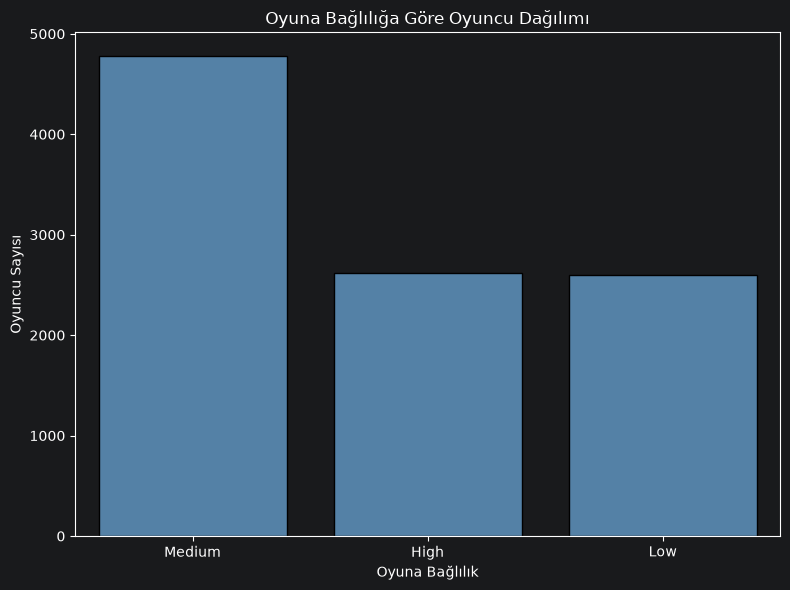

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/kaggle_dataset.csv")

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x="OyunaBaglilik", order=df["OyunaBaglilik"].value_counts().index,color="steelblue", edgecolor="black")
plt.title("Oyuna Bağlılığa Göre Oyuncu Dağılımı")
plt.xlabel("Oyuna Bağlılık")
plt.ylabel("Oyuncu Sayısı")
plt.tight_layout()
plt.show()

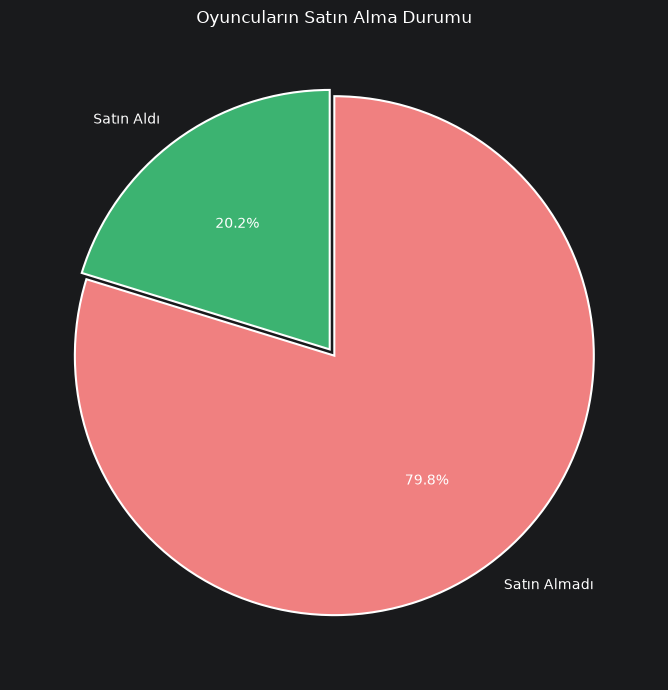

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/kaggle_dataset.csv")


satin_aldi = (df["TotalSatınAlma"] > 0).sum()
satin_almadi = (df["TotalSatınAlma"] == 0).sum()

etiketler = ["Satın Aldı", "Satın Almadı"]
degerler = [satin_aldi, satin_almadi]
renkler = ["mediumseagreen", "lightcoral"]

plt.figure(figsize=(7, 7))
plt.pie(
    degerler,
    labels=etiketler,
    autopct="%1.1f%%",
    colors=renkler,
    startangle=90,
    explode=(0.03, 0),
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
plt.title("Oyuncuların Satın Alma Durumu")
plt.tight_layout()
plt.show()

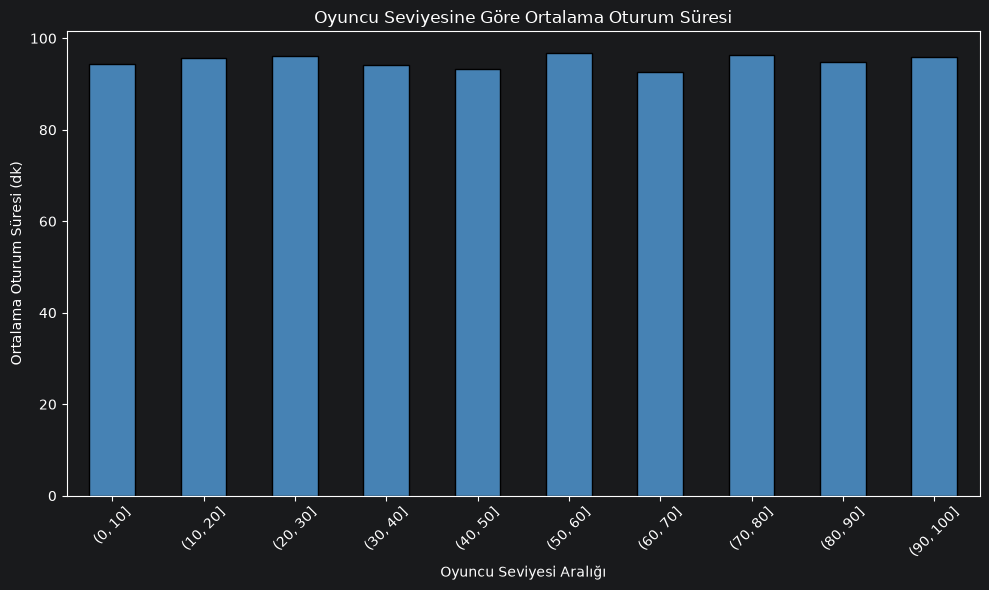

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/kaggle_dataset.csv")

max_seviye = int(df["OyuncuSeviyesi"].max()) + 1
bins = list(range(0, max_seviye + 10, 10))
df["Seviye_Grup"] = pd.cut(df["OyuncuSeviyesi"], bins=bins, precision=0)

grup_ortalama = df.groupby("Seviye_Grup", observed=True)["Ortalama_Oturum_Suresi"].mean()

plt.figure(figsize=(10, 6))
grup_ortalama.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Oyuncu Seviyesine Göre Ortalama Oturum Süresi")
plt.xlabel("Oyuncu Seviyesi Aralığı")
plt.ylabel("Ortalama Oturum Süresi (dk)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()